# Algorithm testing: Tigramite

## Prelims

Original repo here: (https://github.com/jakobrunge/tigramite)

Libraries used:

In [10]:
!pip install numpy pandas matplotlib tigramite scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [11]:
import numpy as np
import matplotlib.pyplot as plt

import tigramite
from tigramite import data_processing as dp
from tigramite.toymodels import structural_causal_processes as toys
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.toymodels.structural_causal_processes import links_to_graph

## Data generation

For Tigramite we have to manually write up the underlying links between the nodes across time (in `links_coeff`). Note that a node can have multiple parent nodes at different time lags, and can also be its own parent (autocorrelation). Here is how to read the `links_coeff` dictionary:

child node: array of ((parent node, time lag), coefficient, function)

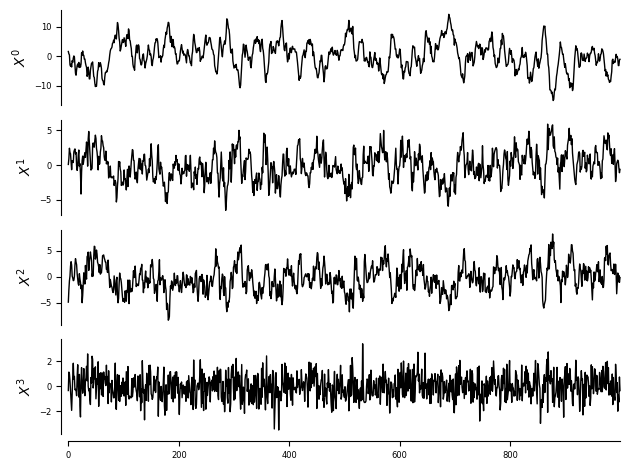

In [12]:
np.random.seed(42) 

def lin_f(x): return x 
links_coeffs = {
    0: [((0, -1), 0.7, lin_f), ((1, -1), -0.8, lin_f)],
    1: [((1, -1), 0.8, lin_f), ((3, -1), 0.8, lin_f)],
    2: [((2, -1), 0.5, lin_f), ((1, -2), 0.5, lin_f), ((3, -3), 0.6, lin_f)],
    3: [] 
}

T = 1000 
data, _ = toys.structural_causal_process(links_coeffs, T=T)

var_names = [r'$X^0$', r'$X^1$', r'$X^2$', r'$X^3$']
dataframe = dp.DataFrame(data, datatime={0:np.arange(len(data))}, var_names=var_names)

# Plot the time series generated by the process
tp.plot_timeseries(dataframe)
plt.show()

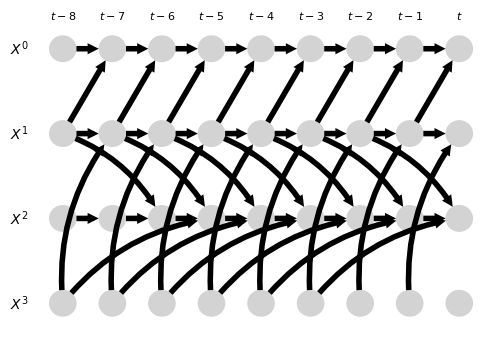

In [13]:
# plot the true graph of the process
true_graph = links_to_graph(links_coeffs, tau_max=8)
tp.plot_time_series_graph(
    figsize=(6, 4),
    graph=true_graph,
    var_names=var_names,
    link_colorbar_label='MCI'
)
plt.show()

Note: this is the cross-time causal structure. check with the hardcoded links to see how the coded links correspond to the graph structure

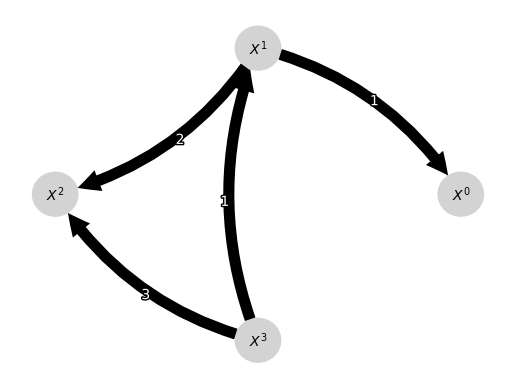

In [14]:
tp.plot_graph(
    graph=true_graph,
    var_names=var_names,
    link_colorbar_label='MCI'
)
plt.show()

Note: this is a "collapsed" graph where only links across nodes are shown, labeled with the time lag on the edges. Tigramite model outputs graphed in this manner can display autocorrelation by coloring the nodes themselves (see later)

## Tigramite estimation

Sparsity controllers/model inputs:

tau_max: maximum time lag to consider for links (how far back the model looks for parent nodes)

pc_alpha: tigramite uses a two-step algorithm (PCMCI, which comprises of PC and MCI) where the first step is selecting sets of potential parents for each node. pc_alpha controls this step, setting the significance threshold for keeping potential parents. If set to None, the algorithm will do a grid search to try and find the optimal pc_alpha to use on its own.

alpha_level: after MCI the model outputs p-values for each link. alpha_level is the significance threshold for which links to keep in the final output graph

In [15]:
# run PCMCI
# np.random.seed(42) <- doesn't actually standardize PCMCI output?
tau_max = 8        # default 1
pc_alpha = 0.2     # default 0.2
alpha_level = 0.05 # default 0.05

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=1)
results = pcmci.run_pcmci(tau_max=tau_max, pc_alpha=pc_alpha, alpha_level=alpha_level)


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 8
pc_alpha = [0.2]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable $X^0$ has 5 link(s):
        ($X^0$ -1): max_pval = 0.00000, |min_val| =  0.806
        ($X^1$ -1): max_pval = 0.00000, |min_val| =  0.693
        ($X^3$ -7): max_pval = 0.06031, |min_val| =  0.060
        ($X^3$ -5): max_pval = 0.18731, |min_val| =  0.042
        ($X^3$ -2): max_pval = 0.18938, |min_val| =  0.042

    Variable $X^1$ has 2 link(s):
        ($X^1$ -1): max_pval = 0.00000, |min_val| =  0.622
        ($X^3$ -1): max_pval = 0.00000, |min_val| =  0.378

    Variable $X^2$ has 5 link(s):
        ($X^1$ -2): max_pval = 0.00000, |min_val| =  0.472
        ($X^2$ -1): max_pval = 0.00000, |min_val| =  0.383
        ($X^3$ -3): max_pval = 0.00000, |min_val| =  0.169
        ($X^3$ -4): max_pval = 0.04716, |min_val| =  0.063
        ($X^2$

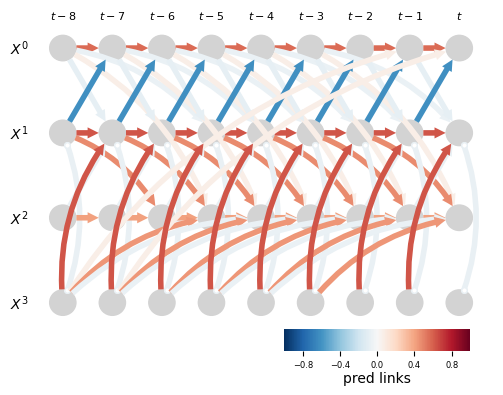

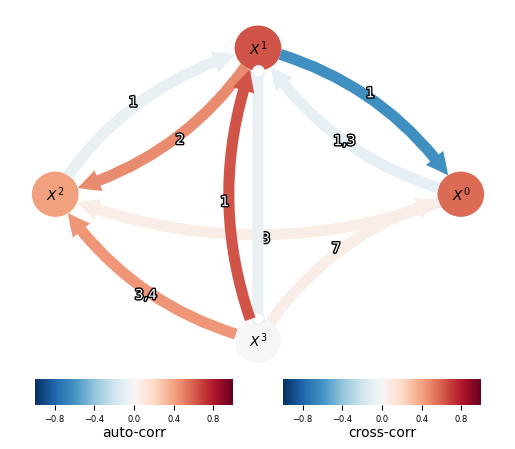

In [16]:
tp.plot_time_series_graph(
    figsize=(6, 4),
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='pred links'
)
plt.show()

tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='cross-corr',
    node_colorbar_label='auto-corr'
)
plt.show()

Note: strangely, seeding the rng doesn't actually keep the PCMCI output the same. If errors are observed though, they are commonly seen as very weak edges, and all of the ground truth edges are often still present. Precision vs recall and F1 scores calculated in the cell below. 

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

true_graph = links_to_graph(links_coeffs, tau_max=8)
true_skeleton = (true_graph!= "").flatten() # binarize

pred_skeleton = (results['graph']!= "").flatten() # binarize

precision = precision_score(true_skeleton, pred_skeleton)
recall = recall_score(true_skeleton, pred_skeleton)
f1 = f1_score(true_skeleton, pred_skeleton)

print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1 Score:  {f1:.2f}\n")

abs_err = np.sum(true_graph != results['graph'])

print(f"Absolute number of errors: {abs_err}")

Precision: 0.47
Recall:    1.00
F1 Score:  0.64

Absolute number of errors: 8


## Tigramite on real dataset

Using data folder from HCP patient dataset, found in exercise_3 folder.

In [18]:
# `file_id` should be an integer between 1 and 11.
def load_data(file_id):
    # fix path as needed
    filename = f'data/HCPcombined_HO110_25_GM_Finn_noTsmooth_RL_step35_nSub80_{file_id}.tsv'
    return np.loadtxt(filename, delimiter='	', skiprows=1)

f1_data = load_data(1)
var_names_file = 'data/parcel_labels.npy'
var_names = np.load(var_names_file)

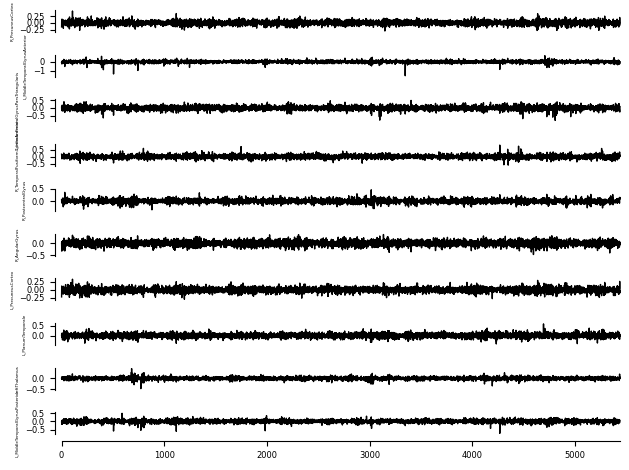

In [19]:
# plot only the first 10 variables
# randomly select 10 variables to plot
# np.random.seed(42)

selected_vars = np.random.choice(len(var_names), size=10, replace=False)
top10_data = f1_data[:, selected_vars]
top10_var_names = var_names[selected_vars]
top10_df = dp.DataFrame(top10_data, datatime={0: np.arange(len(top10_data))}, var_names=top10_var_names)

tp.plot_timeseries(top10_df, label_fontsize=3)
plt.show()

In [20]:
tau_max = 5         # default 1
pc_alpha = 0.05    # default 0.2
alpha_level = 0.001 # default 0.05

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=top10_df, cond_ind_test=parcorr, verbosity=1)
results = pcmci.run_pcmci(tau_max=tau_max, pc_alpha=pc_alpha, alpha_level=alpha_level)


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 5
pc_alpha = [0.05]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable R_PrecuneusCortex has 4 link(s):
        (L_PrecuneusCortex -1): max_pval = 0.00001, |min_val| =  0.062
        (R_PrecuneusCortex -3): max_pval = 0.00318, |min_val| =  0.040
        (L_MiddleTemporalGyrusPosterior -3): max_pval = 0.01437, |min_val| =  0.033
        (R_PostcentralGyrus -3): max_pval = 0.04258, |min_val| =  0.028

    Variable L_MiddleTemporalGyrusAnterior has 5 link(s):
        (L_MiddleTemporalGyrusAnterior -3): max_pval = 0.00324, |min_val| =  0.040
        (R_AngularGyrus -1): max_pval = 0.00638, |min_val| =  0.037
        (L_MiddleTemporalGyrusPosterior -4): max_pval = 0.00818, |min_val| =  0.036
        (L_PrecuneusCortex -1): max_pval = 0.01092, |min_val| =  0.035
        (R_TemporalFusiformCortexAnterior -3): max_pval =

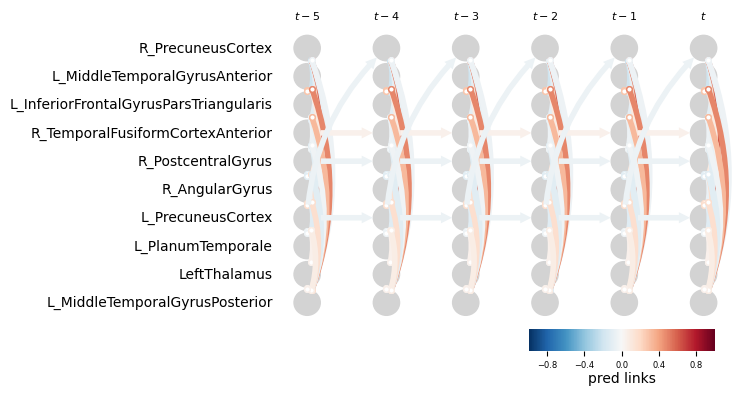

In [21]:
tp.plot_time_series_graph(
    figsize=(6, 4),
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=top10_var_names,
    link_colorbar_label='pred links'
)
plt.show()

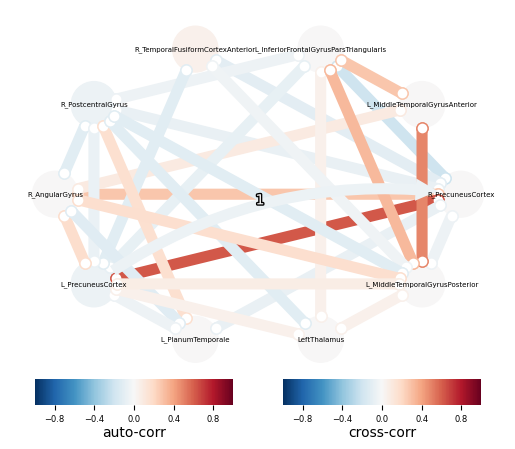

In [22]:
tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=top10_var_names,
    link_colorbar_label='cross-corr',
    node_colorbar_label='auto-corr',
    node_label_size=5
)
plt.show()

Results are not really interpretable, even with `pc_alpha` and `alpha_level` set to 0.001